<a href="https://colab.research.google.com/github/sumaiyaSultanaTarin/AML-nucleus-cytoplasm-segmentation/blob/main/AML_FullPlan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##**SETUP**

In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

PROJECT_ROOT = "/content/drive/MyDrive/AML_ratio_project"
DATA_DIR = os.path.join(PROJECT_ROOT, "data")
CHECKPOINT_DIR = os.path.join(PROJECT_ROOT, "checkpoints")
LOG_DIR = os.path.join(PROJECT_ROOT, "logs")

for folder in [PROJECT_ROOT, DATA_DIR, CHECKPOINT_DIR, LOG_DIR]:
    os.makedirs(folder, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Data dir:", DATA_DIR)
print("Checkpoint dir:", CHECKPOINT_DIR)
print("Log dir:", LOG_DIR)

Project root: /content/drive/MyDrive/AML_ratio_project
Data dir: /content/drive/MyDrive/AML_ratio_project/data
Checkpoint dir: /content/drive/MyDrive/AML_ratio_project/checkpoints
Log dir: /content/drive/MyDrive/AML_ratio_project/logs


In [3]:
REPO_URL = "https://github.com/sumaiyaSultanaTarin/AML-nucleus-cytoplasm-segmentation.git"
REPO_DIR = "/content/AML-nucleus-cytoplasm-segmentation"

if not os.path.exists(REPO_DIR):
    print("Cloning repo...")
    !git clone {REPO_URL} {REPO_DIR}
else:
    print("Repo already cloned, pulling latest changes...")
    !cd {REPO_DIR} && git pull

import sys
sys.path.append(REPO_DIR)

Cloning repo...
Cloning into '/content/AML-nucleus-cytoplasm-segmentation'...
remote: Enumerating objects: 21, done.
remote: Counting objects: 100% (21/21), done.
remote: Compressing objects: 100% (18/18), done.
remote: Total 21 (delta 4), reused 8 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (21/21), 3.70 MiB | 14.18 MiB/s, done.
Resolving deltas: 100% (4/4), done.


In [4]:
# Install packages
!pip install -q segmentation-models-pytorch albumentations opencv-python-headless scikit-image statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 5.7 MB/s eta 0:00:00


In [5]:
import torch

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
    print("GPU memory:", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1), "GB")
else:
    print("No GPU detected")

CUDA available: True
GPU name: Tesla T4
GPU memory: 15.6 GB


In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


**Download WBCAtt+**

In [7]:
# WBCAtt+ images and masks
WBCATT_DIR = os.path.join(DATA_DIR, "wbcattplus")
IMG_MASK_DIR = os.path.join(WBCATT_DIR, "pbcseg_final_v1")
TAR_PATH = os.path.join(WBCATT_DIR, "pbcseg_final_v1.tar")

os.makedirs(WBCATT_DIR, exist_ok=True)

if not os.path.exists(IMG_MASK_DIR):
    print("Images/masks not found in Drive yet, downloading (only happens once)...")

    if not os.path.exists(TAR_PATH):
        !wget -q "https://huggingface.co/datasets/apple2373/wbcattplus/resolve/main/pbcseg_final_v1.tar" -O {TAR_PATH}
        print("Tar file downloaded.")

    !tar -xf {TAR_PATH} -C {WBCATT_DIR}
    print("Extracted.")
else:
    print("Images/masks already in Drive, skipping download.")

n_files = len(os.listdir(IMG_MASK_DIR)) if os.path.exists(IMG_MASK_DIR) else 0
print("Files found in", IMG_MASK_DIR, ":", n_files)

Images/masks already in Drive, skipping download.
Files found in /content/drive/MyDrive/AML_ratio_project/data/wbcattplus/pbcseg_final_v1 : 20596


In [8]:
# WBCAtt+ split CSVs (train/val/test attribute + path tables)
CSV_DIR = os.path.join(WBCATT_DIR, "dataset_txt")
os.makedirs(CSV_DIR, exist_ok=True)

csv_files = [
    "pbc_attr_v1_ccrop_train.csv",
    "pbc_attr_v1_ccrop_val.csv",
    "pbc_attr_v1_ccrop_test.csv",
]

for fname in csv_files:
    fpath = os.path.join(CSV_DIR, fname)
    if not os.path.exists(fpath):
        url = f"https://raw.githubusercontent.com/apple2373/wbcattplus/main/dataset_txt/{fname}"
        !wget -q {url} -O {fpath}
        print("Downloaded", fname)
    else:
        print(fname, "already exists, skipping")

pbc_attr_v1_ccrop_train.csv already exists, skipping
pbc_attr_v1_ccrop_val.csv already exists, skipping
pbc_attr_v1_ccrop_test.csv already exists, skipping


In [9]:
AML_DIR = "/content/drive/MyDrive/PKG - AML-Cytomorphology_LMU"

print("AML-LMU folder exists:", os.path.exists(AML_DIR))
if os.path.exists(AML_DIR):
    print("Top-level contents:", os.listdir(AML_DIR)[:10])

AML-LMU folder exists: True
Top-level contents: ['AML-Cytomorphology.sums', 'BAS', 'EBO', 'EOS', 'KSC', 'LYA', 'LYT', 'MMZ', 'MOB', 'MON']


In [10]:
LOCAL_DATA_DIR = "/content/wbcattplus_data"
IMG_MASK_DIR = os.path.join(LOCAL_DATA_DIR, "pbcseg_final_v1")
os.makedirs(LOCAL_DATA_DIR, exist_ok=True)

if not os.path.exists(IMG_MASK_DIR):
    print("Extracting to local Colab storage (fast, one-time this session)...")
    !tar -xf {TAR_PATH} -C {LOCAL_DATA_DIR}

n_files = len(os.listdir(IMG_MASK_DIR)) if os.path.exists(IMG_MASK_DIR) else 0
print("Files found locally:", n_files)

Extracting to local Colab storage (fast, one-time this session)...
Files found locally: 20596


## **PHASE -01**

**Section 1 - Data (WBCAtt+)**

In [11]:
#1.1 — Load the split CSVs and audit
import pandas as pd

train_df = pd.read_csv(os.path.join(CSV_DIR, "pbc_attr_v1_ccrop_train.csv"))
val_df   = pd.read_csv(os.path.join(CSV_DIR, "pbc_attr_v1_ccrop_val.csv"))
test_df  = pd.read_csv(os.path.join(CSV_DIR, "pbc_attr_v1_ccrop_test.csv"))

print("train:", len(train_df))
print("val:  ", len(val_df))
print("test: ", len(test_df))
print("total:", len(train_df) + len(val_df) + len(test_df))

train: 6169
val:   1030
test:  3099
total: 10298


In [12]:
#1.2 — Check mask pixel value
import cv2
import numpy as np

sample_paths = train_df["path"].sample(50, random_state=42).tolist()
all_values = set()

for p in sample_paths:
    mask_path = os.path.join(IMG_MASK_DIR, p).replace(".jpg", "_mask.png")
    mask = cv2.imread(mask_path, cv2.IMREAD_UNCHANGED)

    if mask is not None:
        all_values.update(np.unique(mask).tolist())
    else:
        print("Mask not found for", p)

print("unique mask values across 50 images:", sorted(all_values))

unique mask values across 50 images: [0, 1, 2, 3, 4, 5]


In [13]:
def mask_to_classes(mask):
    """
    Raw WBCAtt+ mask (6 classes):
      0 = background, 1 = cytoplasm, 2 = nucleus,
      3 = red blood cell, 4 = platelet, 5 = vacuole

    Remapped to 3 training classes:
      0 = background (includes RBC, platelet)
      1 = cytoplasm  (includes vacuole)
      2 = nucleus
    """
    new_mask = np.zeros_like(mask, dtype=np.uint8)
    new_mask[mask == 1] = 1   # cytoplasm
    new_mask[mask == 5] = 1   # vacuole -> cytoplasm
    new_mask[mask == 2] = 2   # nucleus
    return new_mask

In [14]:
#1.4 — Dataset class
import torch
from torch.utils.data import Dataset

class WBCAttDataset(Dataset):
    def __init__(self, df, image_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = self.df.loc[idx, "path"]
        img_path = os.path.join(self.image_dir, img_name)
        mask_path = img_path.replace(".jpg", "_mask.png")

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(mask_path, cv2.IMREAD_UNCHANGED)
        mask = mask_to_classes(mask)

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"]
            mask = augmented["mask"]

        return image, mask.long()

In [15]:
#1.5 — Augmentation AND Dataloaders
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import DataLoader

IMG_SIZE = 360   # native WBCAtt+ resolution
BATCH_SIZE = 8

train_aug = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Rotate(limit=15, p=0.5),
    A.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.05, p=0.3),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

val_aug = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

train_dataset = WBCAttDataset(train_df, IMG_MASK_DIR, transform=train_aug)
val_dataset   = WBCAttDataset(val_df,   IMG_MASK_DIR, transform=val_aug)
test_dataset  = WBCAttDataset(test_df,  IMG_MASK_DIR, transform=val_aug)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
print("train batches:", len(train_loader))
print("val batches:  ", len(val_loader))
print("test batches: ", len(test_loader))

train batches: 772
val batches:   129
test batches:  388


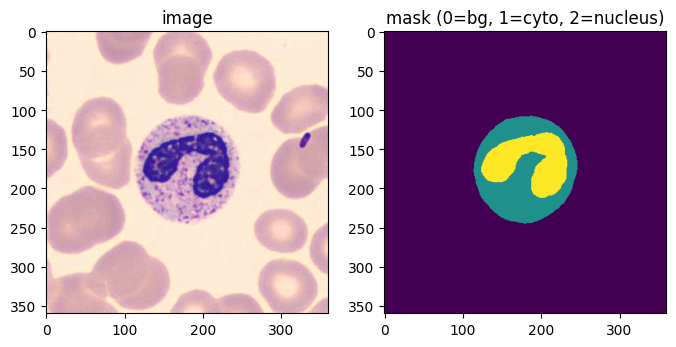

In [16]:
import matplotlib.pyplot as plt

image, mask = train_dataset[0]
image_np = image.permute(1, 2, 0).numpy()
image_np = image_np * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
image_np = np.clip(image_np, 0, 1)

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(image_np)
ax[0].set_title("image")
ax[1].imshow(mask, cmap="viridis", vmin=0, vmax=2)
ax[1].set_title("mask (0=bg, 1=cyto, 2=nucleus)")
plt.show()

**Section 2 - Model**

In [17]:
#Ratio Feedback Gate
import torch
import torch.nn as nn
import torch.nn.functional as F
import segmentation_models_pytorch as smp

class RatioFeedbackGate(nn.Module):
    def __init__(self, channels, hidden=8, epsilon=1e-6):
        super().__init__()
        self.epsilon = epsilon
        self.probe_head = nn.Conv2d(channels, 3, kernel_size=1)
        self.mlp = nn.Sequential(
            nn.Linear(1, hidden),
            nn.ReLU(),
            nn.Linear(hidden, channels),
            nn.Sigmoid()
        )

    def forward(self, x):
        probe = self.probe_head(x)
        probe = F.softmax(probe, dim=1)

        cyto = probe[:, 1, :, :]
        nuc = probe[:, 2, :, :]

        nuc_area = nuc.sum(dim=[1, 2])
        cyto_area = cyto.sum(dim=[1, 2])
        ratio = torch.log((nuc_area + self.epsilon) / (cyto_area + self.epsilon))

        gate = self.mlp(ratio.unsqueeze(1))
        gate = gate.view(gate.size(0), gate.size(1), 1, 1)

        out = x + x * gate
        return out


class SegModel(nn.Module):
    def __init__(self, backbone, num_classes=3, use_rfg=True):
        super().__init__()

        if backbone == "attention_unet":
            base = smp.Unet(encoder_name="resnet34", encoder_weights="imagenet",
                             decoder_attention_type="scse", in_channels=3, classes=num_classes)
        elif backbone == "unet":
            base = smp.Unet(encoder_name="resnet34", encoder_weights="imagenet",
                             in_channels=3, classes=num_classes)

        self.encoder = base.encoder
        self.decoder = base.decoder
        self.seg_head = base.segmentation_head
        self.use_rfg = use_rfg

        if use_rfg:
            channels = self.seg_head[0].in_channels
            self.rfg = RatioFeedbackGate(channels)

    def forward(self, x):
        features = self.encoder(x)
        d = self.decoder(features)
        if self.use_rfg:
            d = self.rfg(d)
        out = self.seg_head(d)
        return out


def make_model(backbone, num_classes=3, use_rfg=True):
    return SegModel(backbone, num_classes, use_rfg)

In [18]:
for backbone in ["attention_unet", "unet"]:
    for use_rfg in [True, False]:
        model = make_model(backbone, num_classes=3, use_rfg=use_rfg)
        model = model.to(device)

        dummy_input = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(device)
        output = model(dummy_input)

        n_params = sum(p.numel() for p in model.parameters())
        print(f"{backbone:15s} use_rfg={str(use_rfg):5s} output={tuple(output.shape)} params={n_params:,}")


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 87.3MB            

model.safetensors: downloading bytes:           |  0.00B            

attention_unet  use_rfg=True  output=(2, 3, 360, 360) params=24,550,861
attention_unet  use_rfg=False output=(2, 3, 360, 360) params=24,550,650
unet            use_rfg=True  output=(2, 3, 360, 360) params=24,436,870
unet            use_rfg=False output=(2, 3, 360, 360) params=24,436,659


In [19]:
model = make_model("attention_unet", num_classes=3, use_rfg=True)
model = model.to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f"Model ready on {device}")
print(f"Total parameters: {n_params:,}")

Model ready on cuda
Total parameters: 24,550,861


**Section 3 - Loss**

In [20]:
#3.1 — Dice + Focal (standard segmentation losses)

class DiceLoss(nn.Module):
    def __init__(self, epsilon=1e-6):
        super().__init__()
        self.epsilon = epsilon

    def forward(self, logits, targets):
        probs = F.softmax(logits, dim=1)
        num_classes = probs.shape[1]
        targets_onehot = F.one_hot(targets, num_classes).permute(0, 3, 1, 2).float()

        dims = (0, 2, 3)
        intersection = torch.sum(probs * targets_onehot, dims)
        union = torch.sum(probs + targets_onehot, dims)

        dice_per_class = (2 * intersection + self.epsilon) / (union + self.epsilon)
        return 1 - dice_per_class.mean()


class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0):
        super().__init__()
        self.gamma = gamma

    def forward(self, logits, targets):
        ce_loss = F.cross_entropy(logits, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        return focal_loss.mean()

In [21]:
#3.2 — Ratio-consistency loss

class RatioConsistencyLoss(nn.Module):
    def __init__(self, epsilon=1e-6):
        super().__init__()
        self.epsilon = epsilon
        self.huber = nn.HuberLoss()

    def forward(self, logits, targets):
        probs = F.softmax(logits, dim=1)

        pred_nuc = probs[:, 2, :, :].sum(dim=[1, 2])
        pred_cyto = probs[:, 1, :, :].sum(dim=[1, 2])
        pred_ratio = torch.log((pred_nuc + self.epsilon) / (pred_cyto + self.epsilon))

        true_nuc = (targets == 2).float().sum(dim=[1, 2])
        true_cyto = (targets == 1).float().sum(dim=[1, 2])
        true_ratio = torch.log((true_nuc + self.epsilon) / (true_cyto + self.epsilon))

        return self.huber(pred_ratio, true_ratio)

In [22]:
#3.3 — Combined total loss

class TotalLoss(nn.Module):
    def __init__(self, lambda1=0.5, lambda2=0.3):
        super().__init__()
        self.dice = DiceLoss()
        self.focal = FocalLoss()
        self.ratio = RatioConsistencyLoss()
        self.lambda1 = lambda1
        self.lambda2 = lambda2

    def forward(self, logits, targets):
        dice_loss = self.dice(logits, targets)
        focal_loss = self.focal(logits, targets)
        loss = dice_loss + self.lambda1 * focal_loss

        if self.lambda2 > 0:
            ratio_loss = self.ratio(logits, targets)
            loss = loss + self.lambda2 * ratio_loss

        return loss

In [23]:
# Build dummy targets where nucleus is much smaller than cytoplasm
dummy_targets_imbalanced = torch.zeros(2, 360, 360, dtype=torch.long)
dummy_targets_imbalanced[:, 100:260, 100:260] = 1   # big cytoplasm region
dummy_targets_imbalanced[:, 160:200, 160:200] = 2   # small nucleus region
dummy_targets_imbalanced = dummy_targets_imbalanced.to(device)

# predicted logits that get the ratio WRONG (predict too much nucleus)
dummy_logits_bad = torch.zeros(2, 3, 360, 360).to(device)
dummy_logits_bad[:, 2, 100:260, 100:260] = 5.0   # predicts nucleus everywhere cytoplasm should be
dummy_logits_bad[:, 0, :, :] = -5.0

loss_with_ratio = TotalLoss(lambda1=0.5, lambda2=0.3).to(device)
loss_without_ratio = TotalLoss(lambda1=0.5, lambda2=0).to(device)

print("With ratio term:", loss_with_ratio(dummy_logits_bad, dummy_targets_imbalanced).item())
print("Without ratio term:", loss_without_ratio(dummy_logits_bad, dummy_targets_imbalanced).item())

With ratio term: 4.491828918457031
Without ratio term: 3.7106425762176514


**Section 4 - Training Infrastructure**

In [24]:
#4.1 — Metrics (Dice score, N:C ratio error)

def dice_score(logits, targets, num_classes=3, epsilon=1e-6):
    preds = torch.argmax(logits, dim=1)
    dice_per_class = []
    for c in range(num_classes):
        pred_c = (preds == c).float()
        target_c = (targets == c).float()
        intersection = (pred_c * target_c).sum()
        union = pred_c.sum() + target_c.sum()
        dice = (2 * intersection + epsilon) / (union + epsilon)
        dice_per_class.append(dice.item())
    return sum(dice_per_class) / num_classes


def nc_ratio_error(logits, targets, epsilon=1e-6):
    preds = torch.argmax(logits, dim=1)

    pred_nuc = (preds == 2).float().sum(dim=[1, 2])
    pred_cyto = (preds == 1).float().sum(dim=[1, 2])
    pred_ratio = pred_nuc / (pred_cyto + epsilon)

    true_nuc = (targets == 2).float().sum(dim=[1, 2])
    true_cyto = (targets == 1).float().sum(dim=[1, 2])
    true_ratio = true_nuc / (true_cyto + epsilon)

    error = torch.abs(pred_ratio - true_ratio)
    return error.mean().item()

In [25]:
#4.2 — Evaluation helper (runs on val/test set, no gradients)

def evaluate(model, loader, loss_fn):
    model.eval()
    total_loss = 0
    total_dice = 0
    total_ratio_error = 0
    n_batches = 0

    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device)
            masks = masks.to(device)

            logits = model(images)
            loss = loss_fn(logits, masks)

            total_loss += loss.item()
            total_dice += dice_score(logits, masks)
            total_ratio_error += nc_ratio_error(logits, masks)
            n_batches += 1

    return total_loss / n_batches, total_dice / n_batches, total_ratio_error / n_batches

In [26]:
def run_experiment(backbone, use_rfg, use_ratio_loss, seed, max_epochs=50, patience=8):
    torch.manual_seed(seed)
    run_name = f"{backbone}_rfg{int(use_rfg)}_ratio{int(use_ratio_loss)}_seed{seed}"
    checkpoint_path = os.path.join(CHECKPOINT_DIR, run_name + ".pt")
    state_path = os.path.join(CHECKPOINT_DIR, run_name + "_state.pt")

    model = make_model(backbone, num_classes=3, use_rfg=use_rfg).to(device)
    lambda2 = 0.3 if use_ratio_loss else 0
    loss_fn = TotalLoss(lambda1=0.5, lambda2=lambda2).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max_epochs)

    start_epoch = 0
    best_dice = 0
    best_ratio_error = float("inf")
    epochs_no_improve = 0
    history = []

    if os.path.exists(state_path):
        state = torch.load(state_path, map_location=device)
        model.load_state_dict(state["model"])
        optimizer.load_state_dict(state["optimizer"])
        scheduler.load_state_dict(state["scheduler"])
        start_epoch = state["epoch"]
        best_dice = state["best_dice"]
        best_ratio_error = state["best_ratio_error"]
        epochs_no_improve = state["epochs_no_improve"]
        history = state["history"]
        print("Resuming", run_name, "from epoch", start_epoch)
    else:
        print("Starting run:", run_name)

    for epoch in range(start_epoch, max_epochs):
        model.train()
        train_loss, n_batches = 0, 0
        for images, masks in train_loader:
            images, masks = images.to(device), masks.to(device)
            optimizer.zero_grad()
            logits = model(images)
            loss = loss_fn(logits, masks)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            n_batches += 1
        train_loss /= n_batches
        scheduler.step()

        val_loss, val_dice, val_ratio_error = evaluate(model, val_loader, loss_fn)
        print(f"Epoch {epoch+1}: train_loss={train_loss:.4f} val_loss={val_loss:.4f} val_dice={val_dice:.4f} val_ratio_error={val_ratio_error:.4f}")

        history.append({"epoch": epoch + 1, "train_loss": train_loss, "val_loss": val_loss,
                         "val_dice": val_dice, "val_ratio_error": val_ratio_error})

        is_better = (val_dice > best_dice) or (val_dice == best_dice and val_ratio_error < best_ratio_error)
        if is_better:
            best_dice, best_ratio_error, epochs_no_improve = val_dice, val_ratio_error, 0
            torch.save(model.state_dict(), checkpoint_path)
        else:
            epochs_no_improve += 1

        torch.save({"model": model.state_dict(), "optimizer": optimizer.state_dict(),
                    "scheduler": scheduler.state_dict(), "epoch": epoch + 1,
                    "best_dice": best_dice, "best_ratio_error": best_ratio_error,
                    "epochs_no_improve": epochs_no_improve, "history": history}, state_path)

        if epochs_no_improve >= patience:
            print("Early stopping at epoch", epoch + 1)
            break

    history_df = pd.DataFrame(history)
    history_path = os.path.join(LOG_DIR, run_name + "_history.csv")
    history_df.to_csv(history_path, index=False)

    if os.path.exists(state_path):
        os.remove(state_path)

    print("Run finished:", run_name)
    print("Best val dice:", best_dice, "Best val ratio error:", best_ratio_error)

    return {"run_name": run_name, "best_dice": best_dice, "best_ratio_error": best_ratio_error,
            "checkpoint_path": checkpoint_path, "history_path": history_path}

**Section 5 — Run the ablation grid**

In [27]:
configs = []

# Backbone A: Attention U-Net, full 4-way ablation, 3 seeds
for seed in [0, 1, 2]:
    configs.append({"backbone": "attention_unet", "use_rfg": False, "use_ratio_loss": False, "seed": seed})
    configs.append({"backbone": "attention_unet", "use_rfg": False, "use_ratio_loss": True,  "seed": seed})
    configs.append({"backbone": "attention_unet", "use_rfg": True,  "use_ratio_loss": False, "seed": seed})
    configs.append({"backbone": "attention_unet", "use_rfg": True,  "use_ratio_loss": True,  "seed": seed})

# Backbone B: plain U-Net, module on/off, ratio loss always on, 3 seeds
for seed in [0, 1, 2]:
    configs.append({"backbone": "unet", "use_rfg": False, "use_ratio_loss": True, "seed": seed})
    configs.append({"backbone": "unet", "use_rfg": True,  "use_ratio_loss": True, "seed": seed})

print("Total configs:", len(configs))

Total configs: 18


In [28]:
import gc
import torch
gc.collect()
if 'torch' in globals(): torch.cuda.empty_cache()

In [29]:
RESULTS_PATH = os.path.join(LOG_DIR, "all_results.csv")

if os.path.exists(RESULTS_PATH):
    results_df = pd.read_csv(RESULTS_PATH)
    completed_runs = set(results_df["run_name"])
else:
    results_df = pd.DataFrame()
    completed_runs = set()

print("Already completed runs:", len(completed_runs))

for cfg in configs:
    run_name = f"{cfg['backbone']}_rfg{int(cfg['use_rfg'])}_ratio{int(cfg['use_ratio_loss'])}_seed{cfg['seed']}"

    if run_name in completed_runs:
        print("Skipping already-completed run:", run_name)
        continue

    result = run_experiment(
        backbone=cfg["backbone"],
        use_rfg=cfg["use_rfg"],
        use_ratio_loss=cfg["use_ratio_loss"],
        seed=cfg["seed"],
        max_epochs=50,
        patience=8,
    )

    results_df = pd.concat([results_df, pd.DataFrame([result])], ignore_index=True)
    results_df.to_csv(RESULTS_PATH, index=False)

print("All configs done.")
print(results_df)

Already completed runs: 18
Skipping already-completed run: attention_unet_rfg0_ratio0_seed0
Skipping already-completed run: attention_unet_rfg0_ratio1_seed0
Skipping already-completed run: attention_unet_rfg1_ratio0_seed0
Skipping already-completed run: attention_unet_rfg1_ratio1_seed0
Skipping already-completed run: attention_unet_rfg0_ratio0_seed1
Skipping already-completed run: attention_unet_rfg0_ratio1_seed1
Skipping already-completed run: attention_unet_rfg1_ratio0_seed1
Skipping already-completed run: attention_unet_rfg1_ratio1_seed1
Skipping already-completed run: attention_unet_rfg0_ratio0_seed2
Skipping already-completed run: attention_unet_rfg0_ratio1_seed2
Skipping already-completed run: attention_unet_rfg1_ratio0_seed2
Skipping already-completed run: attention_unet_rfg1_ratio1_seed2
Skipping already-completed run: unet_rfg0_ratio1_seed0
Skipping already-completed run: unet_rfg1_ratio1_seed0
Skipping already-completed run: unet_rfg0_ratio1_seed1
Skipping already-completed r

**Section 6 — Results**

In [30]:
results_df = pd.read_csv(RESULTS_PATH)
print("Total rows:", len(results_df))
print()
print(results_df["run_name"].value_counts())

Total rows: 18

run_name
attention_unet_rfg0_ratio0_seed0    1
attention_unet_rfg0_ratio1_seed0    1
attention_unet_rfg1_ratio0_seed0    1
attention_unet_rfg1_ratio1_seed0    1
attention_unet_rfg0_ratio0_seed1    1
attention_unet_rfg0_ratio1_seed1    1
attention_unet_rfg1_ratio0_seed1    1
attention_unet_rfg1_ratio1_seed1    1
attention_unet_rfg0_ratio0_seed2    1
attention_unet_rfg0_ratio1_seed2    1
attention_unet_rfg1_ratio0_seed2    1
attention_unet_rfg1_ratio1_seed2    1
unet_rfg0_ratio1_seed0              1
unet_rfg1_ratio1_seed0              1
unet_rfg0_ratio1_seed1              1
unet_rfg1_ratio1_seed1              1
unet_rfg0_ratio1_seed2              1
unet_rfg1_ratio1_seed2              1
Name: count, dtype: int64


In [31]:
RESULTS_PATH = os.path.join(LOG_DIR, "all_results.csv")
results_df = pd.read_csv(RESULTS_PATH)

if "backbone" not in results_df.columns:
    parsed = results_df["run_name"].str.extract(
        r"^(?P<backbone>.+)_rfg(?P<use_rfg>\d)_ratio(?P<use_ratio_loss>\d)_seed(?P<seed>\d+)$"
    )
    parsed["use_rfg"] = parsed["use_rfg"].astype(bool)
    parsed["use_ratio_loss"] = parsed["use_ratio_loss"].astype(bool)
    parsed["seed"] = parsed["seed"].astype(int)
    results_df = pd.concat([results_df, parsed], axis=1)
    results_df.to_csv(RESULTS_PATH, index=False)  # persist the fix

print(results_df.columns.tolist())

['run_name', 'best_dice', 'best_ratio_error', 'checkpoint_path', 'history_path', 'backbone', 'use_rfg', 'use_ratio_loss', 'seed']


In [32]:
results_df = pd.read_csv(RESULTS_PATH)

parsed = results_df["run_name"].str.extract(
    r"^(?P<backbone>.+)_rfg(?P<use_rfg>\d)_ratio(?P<use_ratio_loss>\d)_seed(?P<seed>\d+)$"
)
results_df["backbone"] = parsed["backbone"]
results_df["use_rfg"] = parsed["use_rfg"].astype(int).astype(bool)
results_df["use_ratio_loss"] = parsed["use_ratio_loss"].astype(int).astype(bool)
results_df["seed"] = parsed["seed"].astype(int)

results_df.to_csv(RESULTS_PATH, index=False)

table = results_df.groupby(["backbone", "use_rfg", "use_ratio_loss"]).agg(
    dice_mean=("best_dice", "mean"),
    dice_std=("best_dice", "std"),
    ratio_err_mean=("best_ratio_error", "mean"),
    ratio_err_std=("best_ratio_error", "std"),
    n_seeds=("seed", "count"),
).reset_index()

table["Dice"] = table["dice_mean"].round(4).astype(str) + " ± " + table["dice_std"].round(4).astype(str)
table["N:C Ratio Error"] = table["ratio_err_mean"].round(4).astype(str) + " ± " + table["ratio_err_std"].round(4).astype(str)

print(table[["backbone", "use_rfg", "use_ratio_loss", "n_seeds", "Dice", "N:C Ratio Error"]].to_string(index=False))

      backbone  use_rfg  use_ratio_loss  n_seeds            Dice N:C Ratio Error
attention_unet    False           False        3 0.9909 ± 0.0001 0.0557 ± 0.0016
attention_unet    False            True        3 0.9906 ± 0.0001  0.0649 ± 0.003
attention_unet     True           False        3    0.9909 ± 0.0  0.0565 ± 0.001
attention_unet     True            True        3 0.9907 ± 0.0001 0.0612 ± 0.0038
          unet    False            True        3    0.9907 ± 0.0 0.0614 ± 0.0033
          unet     True            True        3 0.9906 ± 0.0001 0.0626 ± 0.0008


In [33]:
def per_class_dice(logits, targets, epsilon=1e-6):
    preds = torch.argmax(logits, dim=1)
    names = ["background", "cytoplasm", "nucleus"]
    scores = {}
    for c, name in enumerate(names):
        pred_c = (preds == c).float()
        target_c = (targets == c).float()
        intersection = (pred_c * target_c).sum()
        union = pred_c.sum() + target_c.sum()
        dice = (2 * intersection + epsilon) / (union + epsilon)
        scores[name] = round(dice.item(), 4)
    return scores

best_row = table.sort_values(
    by=["dice_mean", "ratio_err_mean"], ascending=[False, True]
).iloc[0]
print("Best config found:")
print(best_row[["backbone", "use_rfg", "use_ratio_loss", "Dice", "N:C Ratio Error"]])

best_run_name = (
    f"{best_row['backbone']}_rfg{int(best_row['use_rfg'])}"
    f"_ratio{int(best_row['use_ratio_loss'])}_seed0"
)
print("Loading checkpoint:", best_run_name)

best_model = make_model(best_row["backbone"], num_classes=3, use_rfg=bool(best_row["use_rfg"])).to(device)
best_model.load_state_dict(torch.load(os.path.join(CHECKPOINT_DIR, best_run_name + ".pt"), map_location=device))
best_model.eval()

config_groups = table[["backbone", "use_rfg", "use_ratio_loss"]].drop_duplicates()

per_class_results = []
for _, row in config_groups.iterrows():
    run_name = f"{row['backbone']}_rfg{int(row['use_rfg'])}_ratio{int(row['use_ratio_loss'])}_seed0"
    model = make_model(row["backbone"], num_classes=3, use_rfg=bool(row["use_rfg"])).to(device)
    model.load_state_dict(torch.load(os.path.join(CHECKPOINT_DIR, run_name + ".pt"), map_location=device))
    model.eval()

    images, masks = next(iter(val_loader))
    images, masks = images.to(device), masks.to(device)
    with torch.no_grad():
        logits = model(images)

    scores = per_class_dice(logits, masks)
    scores.update({"backbone": row["backbone"], "use_rfg": row["use_rfg"], "use_ratio_loss": row["use_ratio_loss"]})
    per_class_results.append(scores)
    print(run_name, scores)

per_class_df = pd.DataFrame(per_class_results)
per_class_df.to_csv(os.path.join(LOG_DIR, "per_class_dice_all_configs.csv"), index=False)

Best config found:
backbone            attention_unet
use_rfg                      False
use_ratio_loss               False
Dice               0.9909 ± 0.0001
N:C Ratio Error    0.0557 ± 0.0016
Name: 0, dtype: object
Loading checkpoint: attention_unet_rfg0_ratio0_seed0
attention_unet_rfg0_ratio0_seed0 {'background': 0.9996, 'cytoplasm': 0.9913, 'nucleus': 0.9962, 'backbone': 'attention_unet', 'use_rfg': False, 'use_ratio_loss': False}
attention_unet_rfg0_ratio1_seed0 {'background': 0.9996, 'cytoplasm': 0.9903, 'nucleus': 0.9955, 'backbone': 'attention_unet', 'use_rfg': False, 'use_ratio_loss': True}
attention_unet_rfg1_ratio0_seed0 {'background': 0.9996, 'cytoplasm': 0.9912, 'nucleus': 0.9965, 'backbone': 'attention_unet', 'use_rfg': True, 'use_ratio_loss': False}
attention_unet_rfg1_ratio1_seed0 {'background': 0.9996, 'cytoplasm': 0.9907, 'nucleus': 0.9961, 'backbone': 'attention_unet', 'use_rfg': True, 'use_ratio_loss': True}
unet_rfg0_ratio1_seed0 {'background': 0.9995, 'cytoplasm':

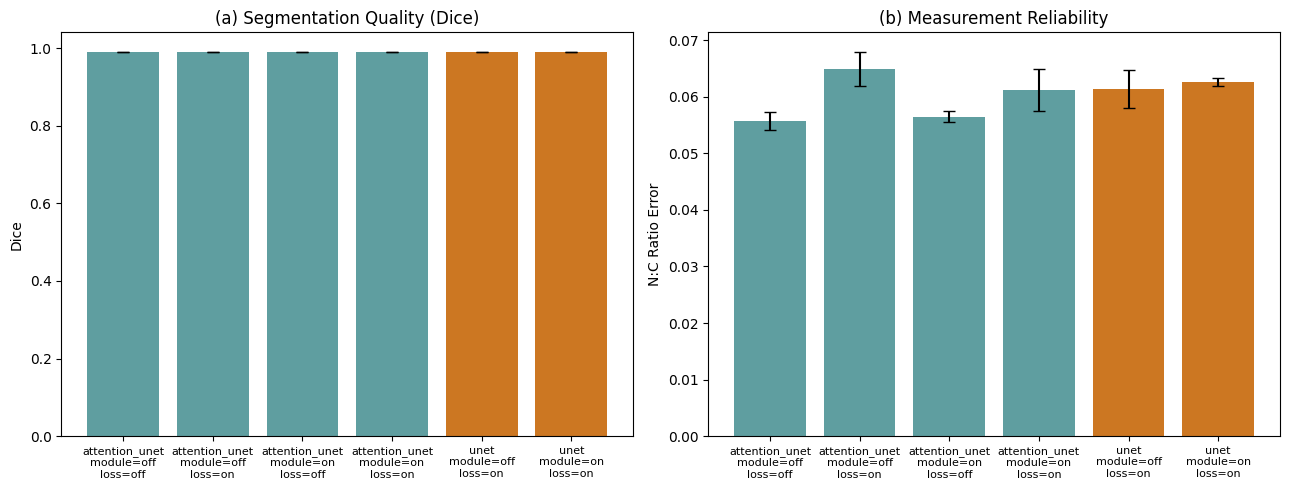

In [34]:
table["config_label"] = table.apply(
    lambda r: f"{r['backbone']}\nmodule={'on' if r['use_rfg'] else 'off'}\nloss={'on' if r['use_ratio_loss'] else 'off'}", axis=1
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = ["#5F9EA0" if b == "attention_unet" else "#CC7722" for b in table["backbone"]]

axes[0].bar(table["config_label"], table["dice_mean"], yerr=table["dice_std"], capsize=4, color=colors)
axes[0].set_ylabel("Dice"); axes[0].set_title("(a) Segmentation Quality (Dice)")
axes[0].tick_params(axis='x', labelsize=8)

axes[1].bar(table["config_label"], table["ratio_err_mean"], yerr=table["ratio_err_std"], capsize=4, color=colors)
axes[1].set_ylabel("N:C Ratio Error"); axes[1].set_title("(b) Measurement Reliability")
axes[1].tick_params(axis='x', labelsize=8)

plt.tight_layout()
plt.savefig(os.path.join(LOG_DIR, "fig_ablation_bars.png"), dpi=300)
plt.show()

RFG mechanism check

In [35]:
def get_probe_ratio(model, images):
    with torch.no_grad():
        features = model.encoder(images)
        d = model.decoder(features)
        probe = torch.softmax(model.rfg.probe_head(d), dim=1)
        cyto, nuc = probe[:, 1], probe[:, 2]
        r = torch.log((nuc.sum(dim=[1,2]) + 1e-6) / (cyto.sum(dim=[1,2]) + 1e-6))
    return r

rfg_configs = ["attention_unet_rfg1_ratio0_seed0", "attention_unet_rfg1_ratio1_seed0", "unet_rfg1_ratio1_seed0"]

correlation_results = []
for run_name in rfg_configs:
    backbone = "attention_unet" if "attention_unet" in run_name else "unet"
    model = make_model(backbone, num_classes=3, use_rfg=True).to(device)
    model.load_state_dict(torch.load(os.path.join(CHECKPOINT_DIR, run_name + ".pt"), map_location=device))
    model.eval()

    images, masks = next(iter(val_loader))
    images, masks = images.to(device), masks.to(device)

    r_pred = get_probe_ratio(model, images)
    true_nuc = (masks == 2).float().sum(dim=[1,2])
    true_cyto = (masks == 1).float().sum(dim=[1,2])
    r_true = torch.log((true_nuc + 1e-6) / (true_cyto + 1e-6))

    correlation = torch.corrcoef(torch.stack([r_pred.cpu(), r_true.cpu()]))[0,1].item()
    correlation_results.append({"run_name": run_name, "correlation": correlation})
    print(f"{run_name}: correlation = {correlation:.4f}")

pd.DataFrame(correlation_results).to_csv(os.path.join(LOG_DIR, "rfg_correlation_check.csv"), index=False)

attention_unet_rfg1_ratio0_seed0: correlation = -0.1917
attention_unet_rfg1_ratio1_seed0: correlation = 0.6346
unet_rfg1_ratio1_seed0: correlation = -0.1315


In [36]:
def get_full_correlation(model, loader):
    all_r_pred, all_r_true = [], []
    for images, masks in loader:
        images, masks = images.to(device), masks.to(device)
        r_pred = get_probe_ratio(model, images)
        true_nuc = (masks == 2).float().sum(dim=[1,2])
        true_cyto = (masks == 1).float().sum(dim=[1,2])
        r_true = torch.log((true_nuc + 1e-6) / (true_cyto + 1e-6))
        all_r_pred.append(r_pred.cpu())
        all_r_true.append(r_true.cpu())
    all_r_pred = torch.cat(all_r_pred)
    all_r_true = torch.cat(all_r_true)
    return torch.corrcoef(torch.stack([all_r_pred, all_r_true]))[0,1].item(), len(all_r_pred)

for run_name in rfg_configs:
    backbone = "attention_unet" if "attention_unet" in run_name else "unet"
    model = make_model(backbone, num_classes=3, use_rfg=True).to(device)
    model.load_state_dict(torch.load(os.path.join(CHECKPOINT_DIR, run_name + ".pt"), map_location=device))
    model.eval()
    corr, n = get_full_correlation(model, val_loader)
    print(f"{run_name}: correlation = {corr:.4f} (n={n} images)")

attention_unet_rfg1_ratio0_seed0: correlation = -0.1312 (n=1030 images)
attention_unet_rfg1_ratio1_seed0: correlation = 0.1969 (n=1030 images)
unet_rfg1_ratio1_seed0: correlation = -0.4478 (n=1030 images)


## **PHASE 02**

In [37]:
def segment_cell_color(image_rgb, erode_size=15, nucleus_v_percentile=35,
                        nucleus_s_percentile=60, min_nucleus_component_frac=0.05):
    """
    image_rgb: HxWx3 uint8 RGB image
    Returns: HxW uint8 mask, 0=background, 1=cytoplasm, 2=nucleus
    """
    hsv = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2HSV)
    h, s, v = hsv[:, :, 0], hsv[:, :, 1], hsv[:, :, 2]

    cell_candidate = ((h > 100) & (h < 180) & (s > 35)).astype(np.uint8)

    noise_kernel = np.ones((3, 3), np.uint8)
    cell_candidate = cv2.morphologyEx(cell_candidate, cv2.MORPH_OPEN, noise_kernel)

    if cell_candidate.sum() == 0:
        return np.zeros(image_rgb.shape[:2], dtype=np.uint8)

    erode_kernel = np.ones((erode_size, erode_size), np.uint8)
    eroded = cv2.erode(cell_candidate, erode_kernel)

    n_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(eroded, connectivity=8)
    H, W = image_rgb.shape[:2]
    center = np.array([W / 2, H / 2])

    if n_labels <= 1:
        main_cell_mask = cell_candidate
    else:
        dists = [np.linalg.norm(centroids[i] - center) for i in range(1, n_labels)]
        seed_label = 1 + int(np.argmin(dists))
        seed_mask = (labels == seed_label).astype(np.uint8)
        grown = cv2.dilate(seed_mask, erode_kernel)
        main_cell_mask = (grown & cell_candidate).astype(np.uint8)

    # --- ADAPTIVE nucleus threshold: based on this cell's own pixel distribution ---
    cell_pixels_mask = main_cell_mask == 1
    v_in_cell = v[cell_pixels_mask]
    s_in_cell = s[cell_pixels_mask]

    if len(v_in_cell) == 0:
        nucleus_mask = np.zeros_like(main_cell_mask)
    else:
        v_thresh = np.percentile(v_in_cell, nucleus_v_percentile)
        s_thresh = np.percentile(s_in_cell, nucleus_s_percentile)

        nucleus_raw = ((v <= v_thresh) & (s >= s_thresh) & cell_pixels_mask).astype(np.uint8)
        nucleus_raw = cv2.morphologyEx(nucleus_raw, cv2.MORPH_CLOSE, np.ones((9, 9), np.uint8))

        # keep only significant connected components, drop speckle noise
        nucleus_mask = np.zeros_like(nucleus_raw)
        n_nuc_labels, nuc_labels, nuc_stats, _ = cv2.connectedComponentsWithStats(nucleus_raw, connectivity=8)

        if n_nuc_labels > 1:
            total_nuc_area = nucleus_raw.sum()
            if total_nuc_area > 0:
                for lbl in range(1, n_nuc_labels):
                    area = nuc_stats[lbl, cv2.CC_STAT_AREA]
                    if area >= min_nucleus_component_frac * total_nuc_area:
                        nucleus_mask[nuc_labels == lbl] = 1
            nucleus_mask = cv2.morphologyEx(nucleus_mask, cv2.MORPH_CLOSE, np.ones((9, 9), np.uint8))
            nucleus_mask = nucleus_mask & main_cell_mask

    mask = np.zeros((H, W), dtype=np.uint8)
    mask[main_cell_mask == 1] = 1
    mask[nucleus_mask == 1] = 2
    return mask

In [38]:
import random

random.seed(42)

blast_classes = ["MYO", "MOB", "PMO", "PMB", "MYB", "MMZ"]
control_classes = ["BAS", "EBO", "EOS", "KSC", "LYA", "LYT", "MON", "NGB", "NGS"]

def sample_class(class_name, n):
    class_dir = os.path.join(AML_DIR, class_name)
    files = [f for f in os.listdir(class_dir) if f.lower().endswith(".tiff")]
    n = min(n, len(files))  # in case a class has fewer than requested
    chosen = random.sample(files, n)
    return [{"class": class_name, "filename": f, "path": os.path.join(class_dir, f)} for f in chosen]

subset = []
for c in blast_classes:
    subset += sample_class(c, 45)
for c in control_classes:
    subset += sample_class(c, 20)

subset_df = pd.DataFrame(subset)
print("Total subset size:", len(subset_df))
print(subset_df["class"].value_counts())

subset_df.to_csv(os.path.join(LOG_DIR, "aml_subset_450.csv"), index=False)

Total subset size: 357
class
MYO    45
PMO    45
MYB    42
MOB    26
BAS    20
EOS    20
EBO    20
NGB    20
NGS    20
MON    20
LYT    20
PMB    18
MMZ    15
KSC    15
LYA    11
Name: count, dtype: int64


In [39]:
AML_MASK_DIR = os.path.join(DATA_DIR, "aml_pseudo_masks")
os.makedirs(AML_MASK_DIR, exist_ok=True)

failed = []

for idx, row in subset_df.iterrows():
    image_bgr = cv2.imread(row["path"])
    if image_bgr is None:
        failed.append(row["path"])
        continue

    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    mask = segment_cell_color(image_rgb, erode_size=35)

    cell_fraction = (mask > 0).mean()
    if cell_fraction < 0.02 or cell_fraction > 0.85:
        failed.append(row["path"])

    mask_filename = row["filename"].replace(".tiff", "_mask.png")
    cv2.imwrite(os.path.join(AML_MASK_DIR, mask_filename), mask)

    if idx % 50 == 0:
        print(f"Processed {idx}/{len(subset_df)}")

print("Done. Flagged as possibly bad:", len(failed))
print(failed[:10])

Processed 0/357
Processed 50/357
Processed 100/357
Processed 150/357
Processed 200/357
Processed 250/357
Processed 300/357
Processed 350/357
Done. Flagged as possibly bad: 3
['/content/drive/MyDrive/PKG - AML-Cytomorphology_LMU/MYO/MYO_3161.tiff', '/content/drive/MyDrive/PKG - AML-Cytomorphology_LMU/KSC/KSC_0015.tiff', '/content/drive/MyDrive/PKG - AML-Cytomorphology_LMU/NGS/NGS_3828.tiff']


In [40]:
def qc_nucleus_fragmentation(mask, max_components=3, min_component_frac=0.05):
    """
    Flags a mask if the nucleus (class 2) is broken into more than
    max_components significant disconnected pieces.
    """
    nucleus = (mask == 2).astype(np.uint8)
    if nucleus.sum() == 0:
        return True, 0

    n_labels, labels, stats, _ = cv2.connectedComponentsWithStats(nucleus, connectivity=8)
    total_area = nucleus.sum()

    component_areas = stats[1:, cv2.CC_STAT_AREA]
    significant = component_areas[component_areas >= min_component_frac * total_area]

    n_significant = len(significant)
    is_bad = n_significant > max_components
    return is_bad, n_significant


frag_flagged = []

for idx, row in subset_df.iterrows():
    mask_path = os.path.join(AML_MASK_DIR, row["filename"].replace(".tiff", "_mask.png"))
    mask = cv2.imread(mask_path, cv2.IMREAD_UNCHANGED)
    if mask is None:
        continue
    is_bad, n_comp = qc_nucleus_fragmentation(mask)
    if is_bad:
        frag_flagged.append({"path": row["path"], "n_components": n_comp})

print("Fragmented nucleus masks flagged:", len(frag_flagged))
for f in frag_flagged[:15]:
    print(f)

Fragmented nucleus masks flagged: 2
{'path': '/content/drive/MyDrive/PKG - AML-Cytomorphology_LMU/MYO/MYO_2002.tiff', 'n_components': 5}
{'path': '/content/drive/MyDrive/PKG - AML-Cytomorphology_LMU/KSC/KSC_0006.tiff', 'n_components': 4}


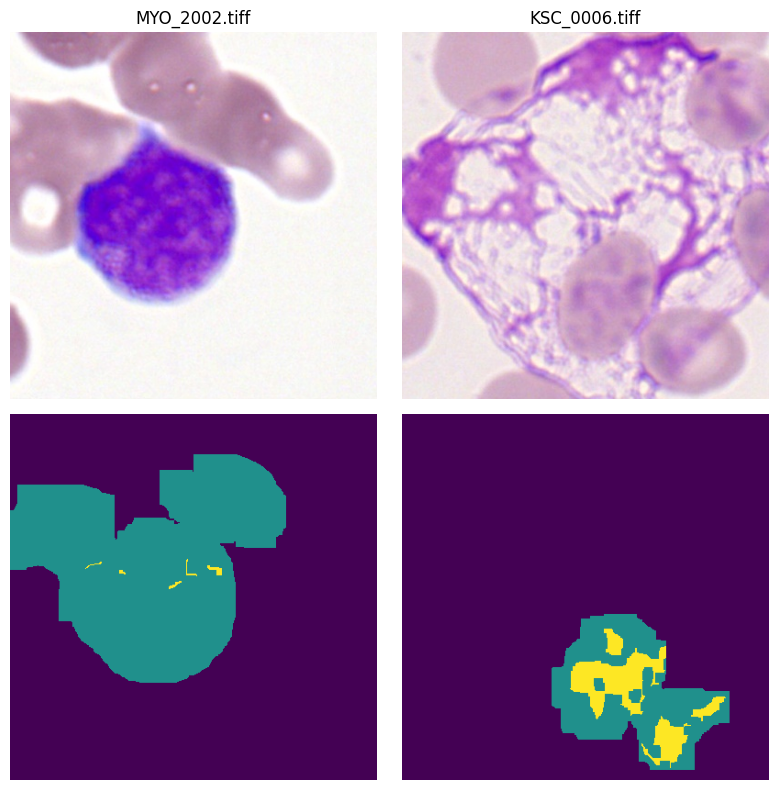

In [41]:
fig, axes = plt.subplots(2, 2, figsize=(8, 8))

for i, path in enumerate([
    "/content/drive/MyDrive/PKG - AML-Cytomorphology_LMU/MYO/MYO_2002.tiff",
    "/content/drive/MyDrive/PKG - AML-Cytomorphology_LMU/KSC/KSC_0006.tiff",
]):
    filename = os.path.basename(path)
    mask_path = os.path.join(AML_MASK_DIR, filename.replace(".tiff", "_mask.png"))

    image_bgr = cv2.imread(path)
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    mask = cv2.imread(mask_path, cv2.IMREAD_UNCHANGED)

    axes[0, i].imshow(image_rgb); axes[0, i].axis("off"); axes[0, i].set_title(filename)
    axes[1, i].imshow(mask, cmap="viridis", vmin=0, vmax=2); axes[1, i].axis("off")

plt.tight_layout()
plt.show()

In [42]:
bad_paths = [
    "/content/drive/MyDrive/PKG - AML-Cytomorphology_LMU/MYO/MYO_2002.tiff",
    "/content/drive/MyDrive/PKG - AML-Cytomorphology_LMU/KSC/KSC_0006.tiff",
]
subset_df = subset_df[~subset_df["path"].isin(bad_paths)].reset_index(drop=True)
print("Subset size after dropping flagged images:", len(subset_df))

Subset size after dropping flagged images: 355


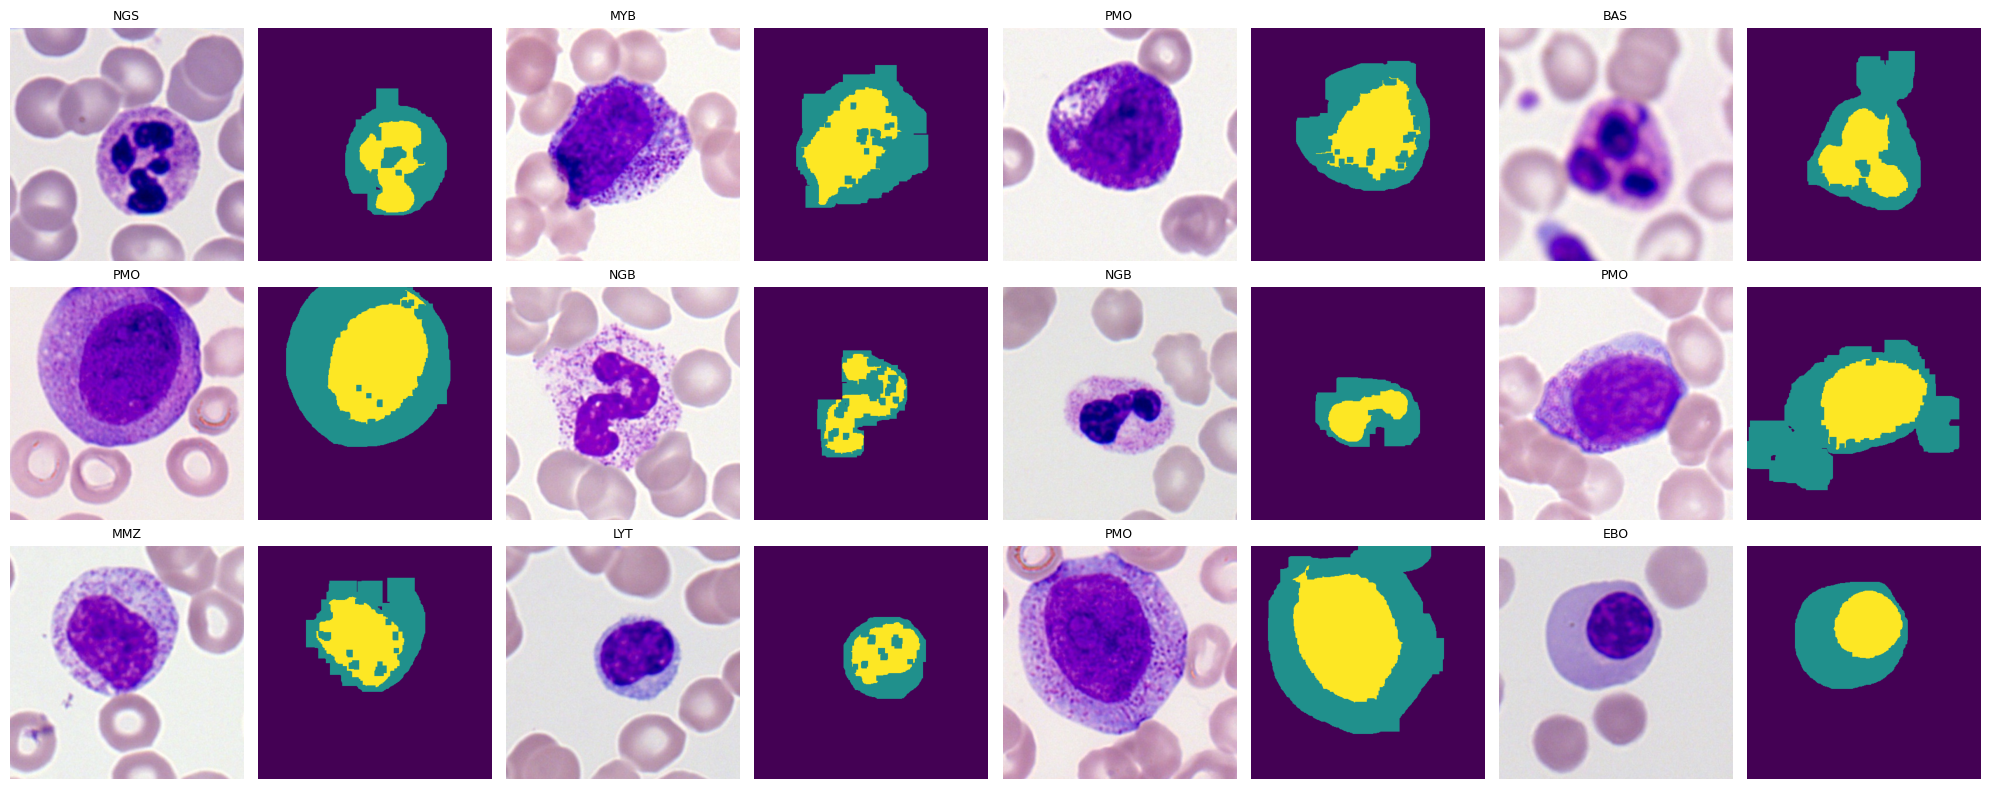

In [43]:
sample_check = subset_df.sample(12, random_state=1)

fig, axes = plt.subplots(3, 8, figsize=(20, 8))
for i, (idx, row) in enumerate(sample_check.iterrows()):
    image_bgr = cv2.imread(row["path"])
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    mask_path = os.path.join(AML_MASK_DIR, row["filename"].replace(".tiff", "_mask.png"))
    mask = cv2.imread(mask_path, cv2.IMREAD_UNCHANGED)

    r = (i // 4)
    c = (i % 4) * 2
    axes[r, c].imshow(image_rgb); axes[r, c].axis("off"); axes[r, c].set_title(row["class"], fontsize=9)
    axes[r, c+1].imshow(mask, cmap="viridis", vmin=0, vmax=2); axes[r, c+1].axis("off")

plt.tight_layout()
plt.show()

**Section 08 - Fine Tuning**

In [44]:
import shutil

LOCAL_AML_DIR = "/content/aml_local"
LOCAL_AML_IMG_DIR = os.path.join(LOCAL_AML_DIR, "images")
LOCAL_AML_MASK_DIR = os.path.join(LOCAL_AML_DIR, "masks")
os.makedirs(LOCAL_AML_IMG_DIR, exist_ok=True)
os.makedirs(LOCAL_AML_MASK_DIR, exist_ok=True)

new_paths = []
for _, row in subset_df.iterrows():
    dst_img = os.path.join(LOCAL_AML_IMG_DIR, row["filename"])
    if not os.path.exists(dst_img):
        shutil.copy(row["path"], dst_img)
    new_paths.append(dst_img)

    mask_filename = row["filename"].replace(".tiff", "_mask.png")
    src_mask = os.path.join(AML_MASK_DIR, mask_filename)
    dst_mask = os.path.join(LOCAL_AML_MASK_DIR, mask_filename)
    if os.path.exists(src_mask) and not os.path.exists(dst_mask):
        shutil.copy(src_mask, dst_mask)

subset_df["path"] = new_paths
AML_MASK_DIR = LOCAL_AML_MASK_DIR

print("Copied", len(subset_df), "images+masks to local storage.")

Copied 355 images+masks to local storage.


In [45]:
from sklearn.model_selection import train_test_split

def safe_split(df, test_size, stratify_col, seed=42):
    try:
        return train_test_split(df, test_size=test_size, stratify=df[stratify_col], random_state=seed)
    except ValueError:
        print("Stratified split failed (some class too small) - falling back to plain random split")
        return train_test_split(df, test_size=test_size, random_state=seed)

train_df, temp_df = safe_split(subset_df, 0.3, "class")
val_df, test_df = safe_split(temp_df, 0.5, "class")
print("train:", len(train_df), "val:", len(val_df), "test:", len(test_df))

train: 248 val: 53 test: 54


In [46]:
class AMLDataset(Dataset):
    def __init__(self, df, mask_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.mask_dir = mask_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.loc[idx, "path"]
        mask_filename = self.df.loc[idx, "filename"].replace(".tiff", "_mask.png")
        mask_path = os.path.join(self.mask_dir, mask_filename)

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(mask_path, cv2.IMREAD_UNCHANGED)

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"]
            mask = augmented["mask"]

        return image, mask.long()

In [47]:
AML_IMG_SIZE = 256  # smaller than WBCAtt+'s 360 - AML images are cropped, this is fine

aml_train_aug = A.Compose([
    A.Resize(AML_IMG_SIZE, AML_IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.2),
    A.Rotate(limit=20, p=0.5),
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.3),
    A.Affine(translate_percent=0.1, scale=(0.9, 1.1), p=0.3),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])
aml_val_aug = A.Compose([
    A.Resize(AML_IMG_SIZE, AML_IMG_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

aml_train_ds = AMLDataset(train_df, AML_MASK_DIR, transform=aml_train_aug)
aml_val_ds = AMLDataset(val_df, AML_MASK_DIR, transform=aml_val_aug)
aml_test_ds = AMLDataset(test_df, AML_MASK_DIR, transform=aml_val_aug)

aml_train_loader = DataLoader(aml_train_ds, batch_size=8, shuffle=True, num_workers=2, pin_memory=True)
aml_val_loader = DataLoader(aml_val_ds, batch_size=8, shuffle=False, num_workers=2, pin_memory=True)
aml_test_loader = DataLoader(aml_test_ds, batch_size=8, shuffle=False, num_workers=2, pin_memory=True)

print("AML train batches:", len(aml_train_loader))
print("AML val batches:", len(aml_val_loader))
print("AML test batches:", len(aml_test_loader))

AML train batches: 31
AML val batches: 7
AML test batches: 7


In [48]:
def fine_tune_on_aml(source_checkpoint_path, backbone, use_rfg, max_epochs=30, patience=6, lr=2.5e-5):
    model = make_model(backbone, num_classes=3, use_rfg=use_rfg).to(device)
    model.load_state_dict(torch.load(source_checkpoint_path, map_location=device))
    print("Loaded pretrained weights from:", source_checkpoint_path)

    run_name = f"aml_finetune_{backbone}_rfg{int(use_rfg)}"

    loss_fn = TotalLoss(lambda1=0.5, lambda2=0.3).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max_epochs)

    best_dice, best_ratio_error, epochs_no_improve = 0, float("inf"), 0
    history = []
    checkpoint_path = os.path.join(CHECKPOINT_DIR, run_name + ".pt")

    for epoch in range(max_epochs):
        model.train()
        train_loss, n_batches = 0, 0
        for images, masks in aml_train_loader:
            images, masks = images.to(device), masks.to(device)
            optimizer.zero_grad()
            logits = model(images)
            loss = loss_fn(logits, masks)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            n_batches += 1
        train_loss /= n_batches
        scheduler.step()

        val_loss, val_dice, val_ratio_error = evaluate(model, aml_val_loader, loss_fn)
        print(f"Epoch {epoch+1}: train_loss={train_loss:.4f} val_dice={val_dice:.4f} val_ratio_error={val_ratio_error:.4f}")

        history.append({"epoch": epoch+1, "train_loss": train_loss, "val_loss": val_loss,
                         "val_dice": val_dice, "val_ratio_error": val_ratio_error})

        is_better = (val_dice > best_dice) or (val_dice == best_dice and val_ratio_error < best_ratio_error)
        if is_better:
            best_dice, best_ratio_error, epochs_no_improve = val_dice, val_ratio_error, 0
            torch.save(model.state_dict(), checkpoint_path)
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            print("Early stopping at epoch", epoch + 1)
            break

    pd.DataFrame(history).to_csv(os.path.join(LOG_DIR, run_name + "_history.csv"), index=False)
    print("Fine-tuning finished. Best val dice:", best_dice, "Best val ratio error:", best_ratio_error)
    return {"run_name": run_name, "best_dice": best_dice, "best_ratio_error": best_ratio_error, "checkpoint_path": checkpoint_path}

In [49]:
best_phase1_checkpoint = os.path.join(CHECKPOINT_DIR, "attention_unet_rfg0_ratio0_seed0.pt")

result = fine_tune_on_aml(best_phase1_checkpoint, backbone="attention_unet", use_rfg=False,  max_epochs=30, patience=6)
print(result)

Loaded pretrained weights from: /content/drive/MyDrive/AML_ratio_project/checkpoints/attention_unet_rfg0_ratio0_seed0.pt
Epoch 1: train_loss=0.6902 val_dice=0.8078 val_ratio_error=0.6517
Epoch 2: train_loss=0.5011 val_dice=0.8213 val_ratio_error=0.4170
Epoch 3: train_loss=0.4562 val_dice=0.8283 val_ratio_error=0.3088
Epoch 4: train_loss=0.3889 val_dice=0.8299 val_ratio_error=0.2496
Epoch 5: train_loss=0.3253 val_dice=0.8344 val_ratio_error=0.2915
Epoch 6: train_loss=0.2959 val_dice=0.8398 val_ratio_error=0.2839
Epoch 7: train_loss=0.2662 val_dice=0.8410 val_ratio_error=0.2086
Epoch 8: train_loss=0.2580 val_dice=0.8452 val_ratio_error=0.2135
Epoch 9: train_loss=0.2497 val_dice=0.8501 val_ratio_error=0.2333
Epoch 10: train_loss=0.2381 val_dice=0.8533 val_ratio_error=0.2135
Epoch 11: train_loss=0.2346 val_dice=0.8559 val_ratio_error=0.2290
Epoch 12: train_loss=0.2218 val_dice=0.8579 val_ratio_error=0.2216
Epoch 13: train_loss=0.2193 val_dice=0.8600 val_ratio_error=0.2308
Epoch 14: train_l

In [52]:
def train_aml_from_scratch(backbone, use_rfg, max_epochs=30, patience=6, lr=2.5e-5):
    model = make_model(backbone, num_classes=3, use_rfg=use_rfg).to(device)
    run_name = f"aml_scratch_{backbone}_rfg{int(use_rfg)}"

    loss_fn = TotalLoss(lambda1=0.5, lambda2=0.3).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max_epochs)

    best_dice, best_ratio_error, epochs_no_improve = 0, float("inf"), 0
    checkpoint_path = os.path.join(CHECKPOINT_DIR, run_name + ".pt")

    for epoch in range(max_epochs):
        model.train()
        for images, masks in aml_train_loader:
            images, masks = images.to(device), masks.to(device)
            optimizer.zero_grad()
            loss = loss_fn(model(images), masks)
            loss.backward()
            optimizer.step()
        scheduler.step()

        val_loss, val_dice, val_ratio_error = evaluate(model, aml_val_loader, loss_fn)
        print(f"Epoch {epoch+1}: val_dice={val_dice:.4f} val_ratio_error={val_ratio_error:.4f}")

        if val_dice > best_dice:
            best_dice, best_ratio_error, epochs_no_improve = val_dice, val_ratio_error, 0
            torch.save(model.state_dict(), checkpoint_path)
        else:
            epochs_no_improve += 1
        if epochs_no_improve >= patience:
            break

    print("Finished. Best val dice:", best_dice, "Best val ratio error:", best_ratio_error)
    return {"run_name": run_name, "best_dice": best_dice, "best_ratio_error": best_ratio_error}

scratch_result = train_aml_from_scratch("attention_unet", use_rfg=False, max_epochs=30, patience=6, lr=1e-4)
print(scratch_result)

Epoch 1: val_dice=0.6480 val_ratio_error=0.4092
Epoch 2: val_dice=0.7865 val_ratio_error=0.3080
Epoch 3: val_dice=0.8130 val_ratio_error=0.3912
Epoch 4: val_dice=0.8373 val_ratio_error=0.2108
Epoch 5: val_dice=0.8507 val_ratio_error=0.2288
Epoch 6: val_dice=0.8408 val_ratio_error=0.3049
Epoch 7: val_dice=0.8603 val_ratio_error=0.2491
Epoch 8: val_dice=0.8498 val_ratio_error=0.2904
Epoch 9: val_dice=0.8735 val_ratio_error=0.3141
Epoch 10: val_dice=0.8719 val_ratio_error=0.2421
Epoch 11: val_dice=0.8804 val_ratio_error=0.2176
Epoch 12: val_dice=0.8825 val_ratio_error=0.2044
Epoch 13: val_dice=0.8878 val_ratio_error=0.1824
Epoch 14: val_dice=0.8930 val_ratio_error=0.1407
Epoch 15: val_dice=0.8890 val_ratio_error=0.2181
Epoch 16: val_dice=0.8819 val_ratio_error=0.1596
Epoch 17: val_dice=0.8927 val_ratio_error=0.1979
Epoch 18: val_dice=0.8979 val_ratio_error=0.1657
Epoch 19: val_dice=0.9000 val_ratio_error=0.1563
Epoch 20: val_dice=0.8976 val_ratio_error=0.1555
Epoch 21: val_dice=0.8998 val

In [53]:
phase2_results = pd.DataFrame([
    {"regime": "AML-only (from scratch)", **scratch_result},
    {"regime": "WBCAtt+ pretrained + fine-tuned", **result},
])
print(phase2_results[["regime", "best_dice", "best_ratio_error"]])
phase2_results.to_csv(os.path.join(LOG_DIR, "phase2_comparison.csv"), index=False)

                            regime  best_dice  best_ratio_error
0          AML-only (from scratch)   0.905352          0.169871
1  WBCAtt+ pretrained + fine-tuned   0.871955          0.208599


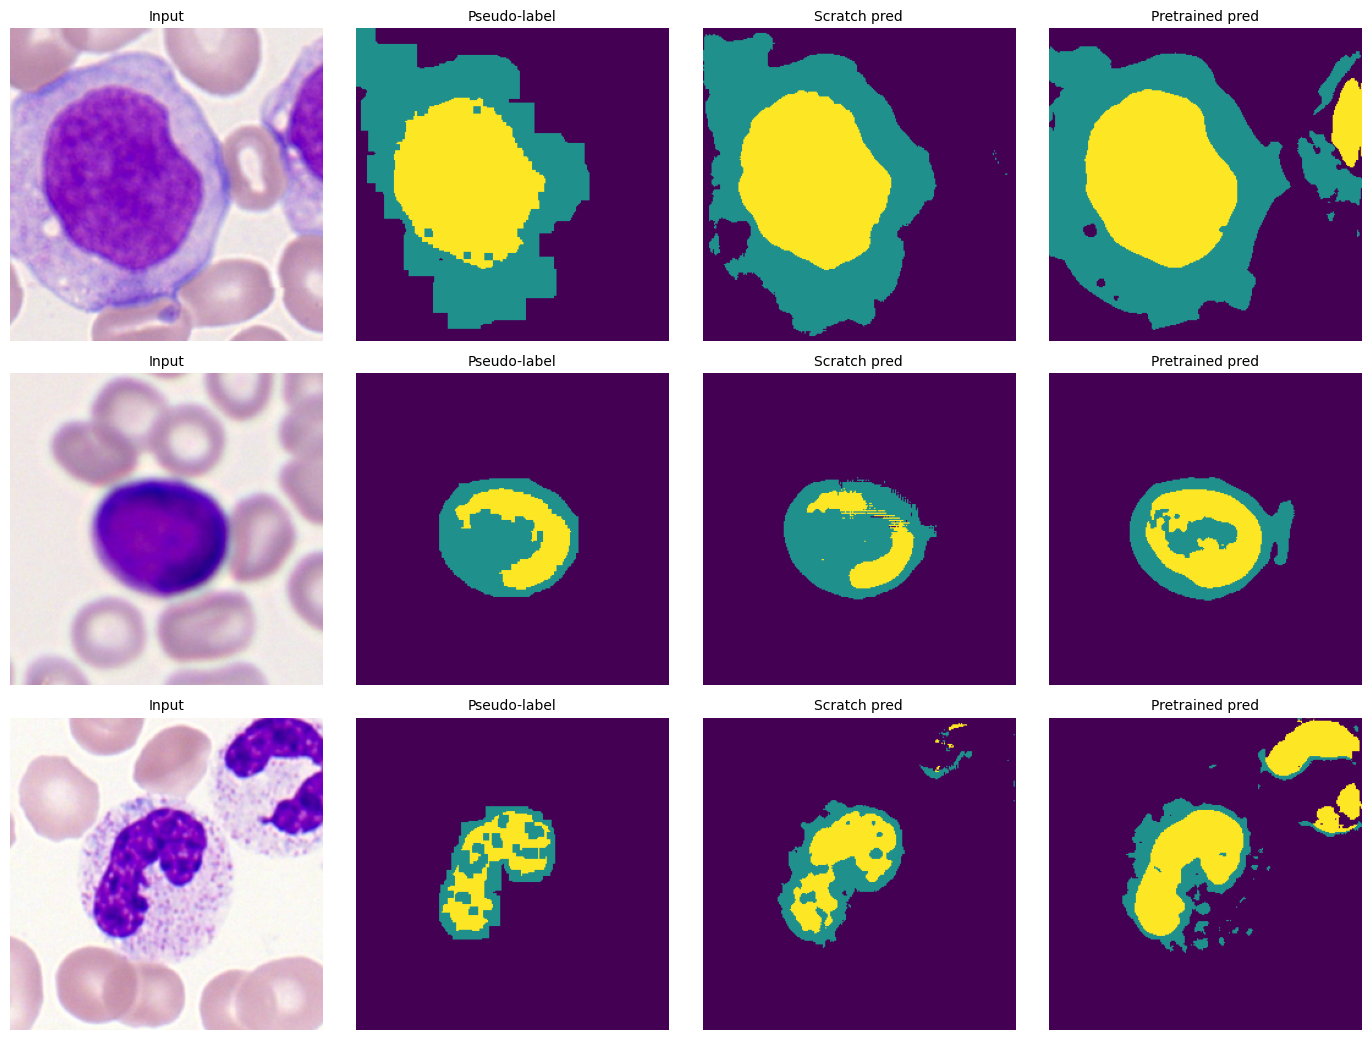

In [54]:
scratch_model = make_model("attention_unet", num_classes=3, use_rfg=False).to(device)
scratch_model.load_state_dict(torch.load(os.path.join(CHECKPOINT_DIR, "aml_scratch_attention_unet_rfg0.pt"), map_location=device))
scratch_model.eval()

pretrained_model = make_model("attention_unet", num_classes=3, use_rfg=False).to(device)
pretrained_model.load_state_dict(torch.load(os.path.join(CHECKPOINT_DIR, "aml_finetune_attention_unet_rfg0.pt"), map_location=device))
pretrained_model.eval()

images, masks = next(iter(aml_test_loader))
images, masks = images.to(device), masks.to(device)

with torch.no_grad():
    scratch_preds = torch.argmax(scratch_model(images), dim=1)
    pretrained_preds = torch.argmax(pretrained_model(images), dim=1)

n_show = min(3, images.size(0))
fig, axes = plt.subplots(n_show, 4, figsize=(14, 3.5 * n_show))
titles = ["Input", "Pseudo-label", "Scratch pred", "Pretrained pred"]

for i in range(n_show):
    img_np = images[i].cpu().permute(1, 2, 0).numpy()
    img_np = img_np * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img_np = np.clip(img_np, 0, 1)

    row_data = [img_np, masks[i].cpu(), scratch_preds[i].cpu(), pretrained_preds[i].cpu()]
    for j in range(4):
        if j == 0:
            axes[i, j].imshow(row_data[j])
        else:
            axes[i, j].imshow(row_data[j], cmap="viridis", vmin=0, vmax=2)
        axes[i, j].set_title(titles[j], fontsize=10)
        axes[i, j].axis("off")

plt.tight_layout()
plt.savefig(os.path.join(LOG_DIR, "fig_phase2_comparison.png"), dpi=300)
plt.show()

In [55]:
def per_class_dice(logits, targets, epsilon=1e-6):
    preds = torch.argmax(logits, dim=1)
    names = ["background", "cytoplasm", "nucleus"]
    scores = {}
    for c, name in enumerate(names):
        pred_c = (preds == c).float()
        target_c = (targets == c).float()
        intersection = (pred_c * target_c).sum()
        union = pred_c.sum() + target_c.sum()
        dice = (2 * intersection + epsilon) / (union + epsilon)
        scores[name] = dice.item()
    return scores

images, masks = next(iter(aml_test_loader))
images, masks = images.to(device), masks.to(device)
with torch.no_grad():
    logits = pretrained_model(images)

print(per_class_dice(logits, masks))

{'background': 0.9756326675415039, 'cytoplasm': 0.7713543176651001, 'nucleus': 0.7981115579605103}


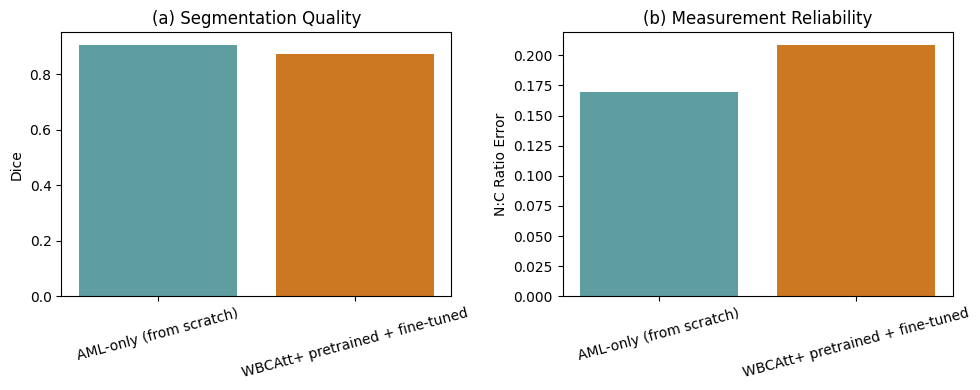

In [56]:
phase2_results = pd.read_csv(os.path.join(LOG_DIR, "phase2_comparison.csv"))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(phase2_results["regime"], phase2_results["best_dice"], color=["#5F9EA0", "#CC7722"])
axes[0].set_ylabel("Dice"); axes[0].set_title("(a) Segmentation Quality")
axes[0].tick_params(axis='x', rotation=15)

axes[1].bar(phase2_results["regime"], phase2_results["best_ratio_error"], color=["#5F9EA0", "#CC7722"])
axes[1].set_ylabel("N:C Ratio Error"); axes[1].set_title("(b) Measurement Reliability")
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig(os.path.join(LOG_DIR, "fig_phase2_bars.png"), dpi=300)
plt.show()